In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

In [5]:
from pathlib import Path

# Try a few common relative locations for the CSV file
candidate_paths = [
	Path("data/Mall_Customers.csv"),
	Path("notebooks/data/Mall_Customers.csv"),
	Path("../data/Mall_Customers.csv"),
	Path("./data/Mall_Customers.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
	raise FileNotFoundError(
		"Could not find 'Mall_Customers.csv'. "
		f"Tried: {', '.join(str(p) for p in candidate_paths)}"
	)

df = pd.read_csv(csv_path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

In [7]:
df["Gender"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

In [8]:
X = df.drop("CustomerID", axis=1)

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(200, 4)


In [10]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

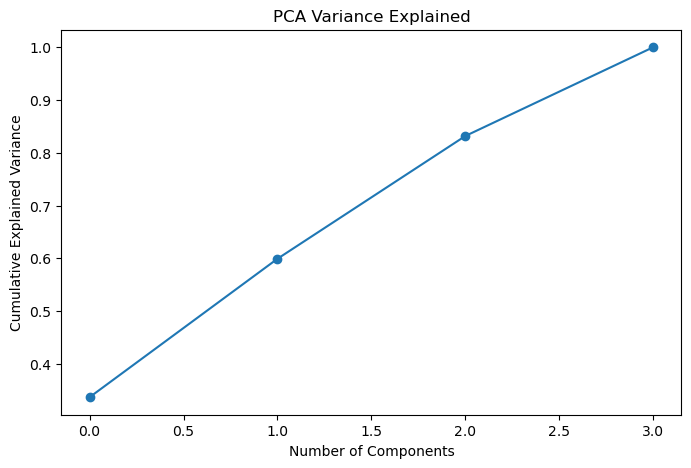

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")

plt.show()

In [12]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X_scaled.shape[1])
print("Reduced Features:", X_pca.shape[1])

Original Features: 4
Reduced Features: 4


In [13]:
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_pca)

    wcss.append(km.inertia_)

d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

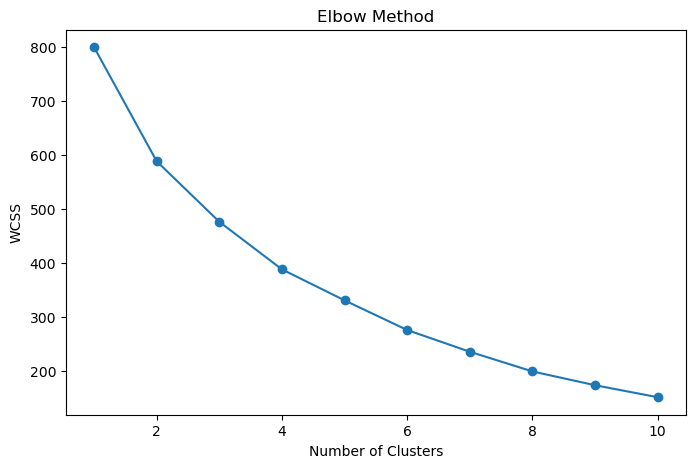

In [15]:
from pathlib import Path

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

images_dir = Path("images")
images_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(images_dir / "elbow_curve.png", bbox_inches="tight")

plt.show()

In [16]:
scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

    print(f"K={k}, Score={score:.4f}")

d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

K=2, Score=0.2518
K=3, Score=0.2595
K=4, Score=0.2984
K=5, Score=0.3041
K=6, Score=0.3311


d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

K=7, Score=0.3574
K=8, Score=0.3880
K=9, Score=0.4031
K=10, Score=0.4208


d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


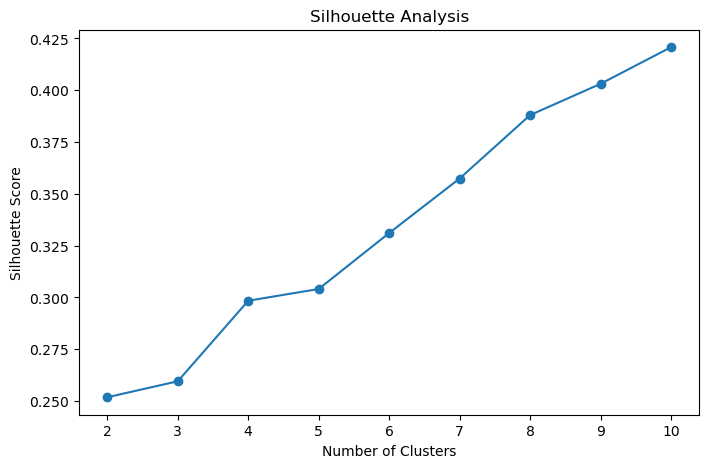

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.savefig("images/silhouette_curve.png")

plt.show()

In [18]:
best_k = 5

In [19]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters

d:\anacondaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


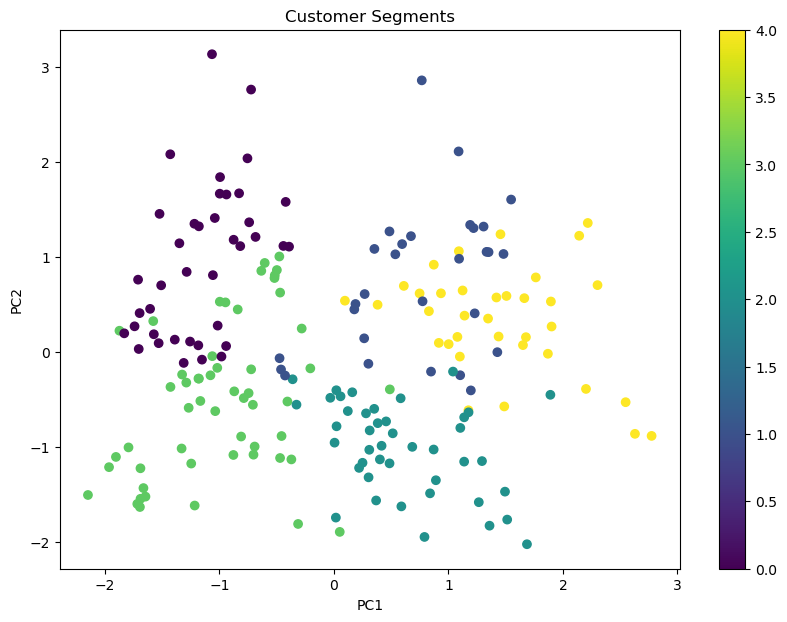

In [20]:
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Customer Segments")

plt.colorbar(scatter)

plt.savefig("images/clusters.png")

plt.show()

In [21]:
cluster_profile = df.groupby(
    "Cluster"
).mean()

print(cluster_profile)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        162.000000  0.538462  32.692308           86.538462   
1        165.482759  0.551724  36.482759           89.517241   
2         73.651163  1.000000  49.813953           49.232558   
3         52.814815  0.592593  24.907407           39.722222   
4         84.685714  0.000000  55.714286           53.685714   

         Spending Score (1-100)  
Cluster                          
0                     82.128205  
1                     18.000000  
2                     40.069767  
3                     61.203704  
4                     36.771429  


In [23]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    scaler,
    models_dir / "scaler.pkl"
)

joblib.dump(
    pca,
    models_dir / "pca.pkl"
)

joblib.dump(
    kmeans,
    models_dir / "kmeans.pkl"
)

['models\\kmeans.pkl']

In [24]:
df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("File Saved")

File Saved
